1 Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

2. Load Dataset

In [3]:
df = pd.read_csv("final_patent_dataset_balanced.csv")

X = df["clean_text"]
y = df["novelty tier"]

3. Train Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

4. Convert Text → TF-IDF

In [5]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

5. Train Models

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = [precision, recall, f1]

6. Confusion Matrix Plot

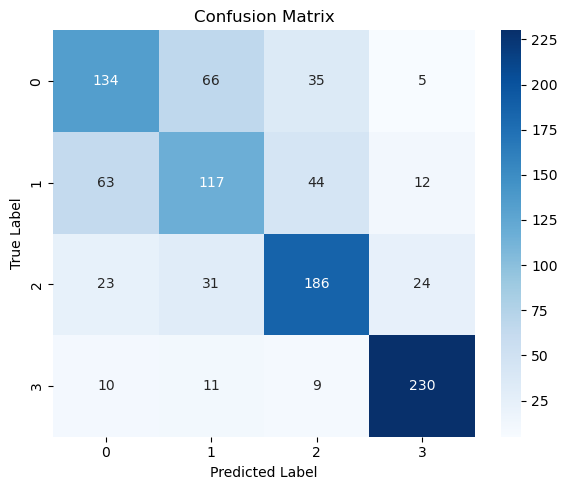

In [14]:
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train_vec, y_train)

y_pred = best_model.predict(X_test_vec)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

7. Precision vs Recall Plot

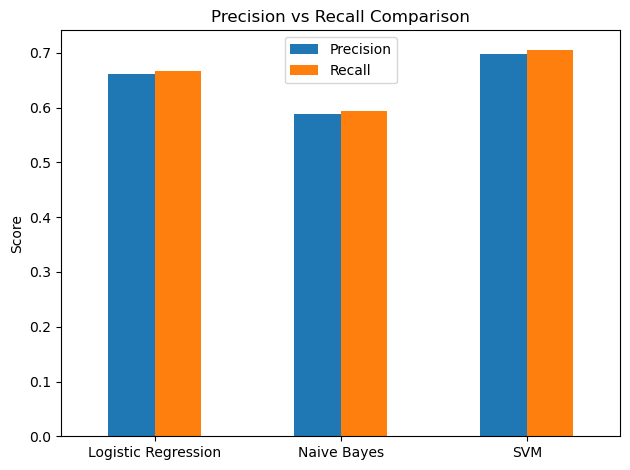

In [15]:
results_df = pd.DataFrame(results, index=["Precision","Recall","F1 Score"]).T

results_df[["Precision","Recall"]].plot(kind="bar")

plt.title("Precision vs Recall Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("precision_recall.png")
plt.show()

8. F1 Score Comparison

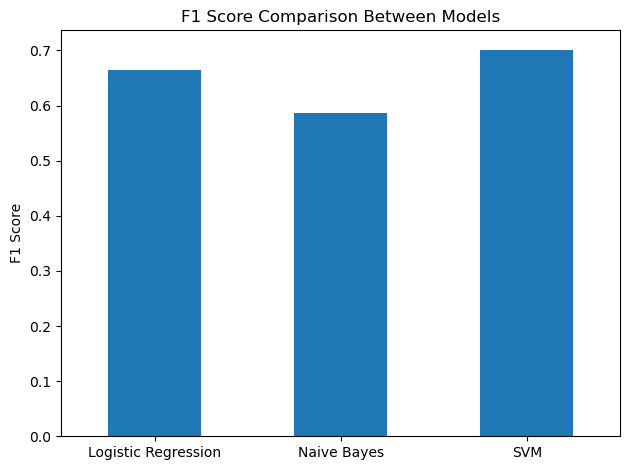

In [16]:
results_df["F1 Score"].plot(kind="bar")

plt.title("F1 Score Comparison Between Models")
plt.ylabel("F1 Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()